In [50]:
import os
from pathlib import Path
%pip install python-dotenv
from dotenv import load_dotenv

load_dotenv()


# Grab the secret key without exposing it
api_key = os.getenv("OPENAI_API_KEY")

# Local paths: files are stored in this project folder.
DATA_DIR = Path(".")
CODES_DIR = DATA_DIR / "Codes"
PDF_DIR = DATA_DIR / "PDFs"

# This Mac uses Apple unified memory. Keep model workloads on the CPU.
COMPUTE_DEVICE = "cpu"

# Set OPENAI_API_KEY in your environment before running the notebook.
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    print("OPENAI_API_KEY is not set. Add it to your environment before using OpenAI features.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd
import numpy as np

%pip install -q -U datasets accelerate evaluate huggingface_hub


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
import pandas as pd
import numpy as np

# Load the diabetes dataset from the project directory.
df = pd.read_csv(
    DATA_DIR / 'diabetic_data.csv',
    dtype={"max_glu_serum": "string", "A1Cresult": "string"},
    keep_default_na=False,
)

columns_to_drop = ['weight', 'citoglipton', 'examide']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Count missing values (NaN/None) and '?' entries by column.
missing_nan = df.isna().sum()
question_mark_counts = (df == '?').sum()
missing_counts = pd.DataFrame({
    'NaN/None_count': missing_nan,
    'Question_mark_count': question_mark_counts,
})
missing_counts['Total_missing'] = missing_counts['NaN/None_count'] + missing_counts['Question_mark_count']
missing_with_values = missing_counts[missing_counts['Total_missing'] > 0].sort_values('Total_missing', ascending=False)

print("\n=== MISSING VALUE SUMMARY ===")
print("\nColumns with missing values:")
print(missing_with_values)
print(f"\n\nTotal missing values in dataset: {missing_counts['Total_missing'].sum()}")
print("\nAll columns summary:")
print(missing_counts.sort_values('Total_missing', ascending=False))

if 'medical_specialty' in df.columns:
    df['medical_specialty'] = df['medical_specialty'].replace('?', 'no specialty')
    print("\nFilled '?' in medical_specialty with 'no specialty'")

# Replace question marks in diagnosis columns with "none".
for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].replace('?', 'none')
        print(f"Replaced '?' with 'none' in {col}")

print(f"Dataset shape: {df.shape}")
print(df.head())

# Convert '>30' to 'NO' in the readmission target.
df['readmitted'] = df['readmitted'].replace('>30', 'NO')
print("\nUpdated 'readmitted' column in df:")
display(df['readmitted'].value_counts())


=== MISSING VALUE SUMMARY ===

Columns with missing values:
                   NaN/None_count  Question_mark_count  Total_missing
medical_specialty               0              49949.0        49949.0
payer_code                      0              40256.0        40256.0
race                            0               2273.0         2273.0
diag_3                          0               1423.0         1423.0
diag_2                          0                358.0          358.0
diag_1                          0                 21.0           21.0


Total missing values in dataset: 94280.0

All columns summary:
                          NaN/None_count  Question_mark_count  Total_missing
medical_specialty                      0              49949.0        49949.0
payer_code                             0              40256.0        40256.0
race                                   0               2273.0         2273.0
diag_3                                 0               1423.0         1423.0

readmitted
NO     90409
<30    11357
Name: count, dtype: int64

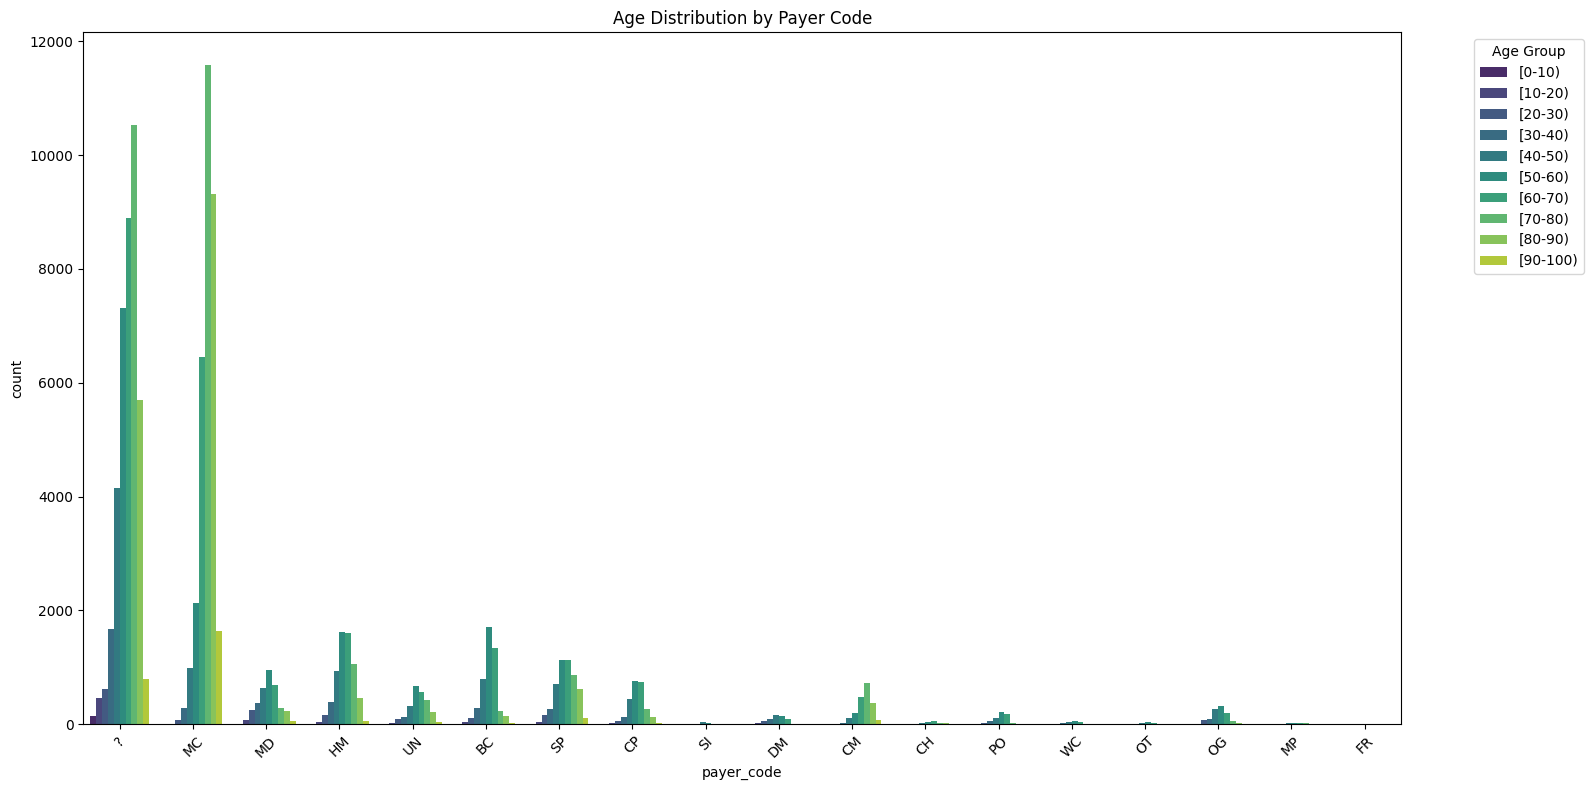

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA: Payer Code and Age Breakdown ---
plt.figure(figsize=(16, 8))
sns.countplot(data=df, x='payer_code', hue='age', palette='viridis')
plt.title('Age Distribution by Payer Code')
plt.xticks(rotation=45)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

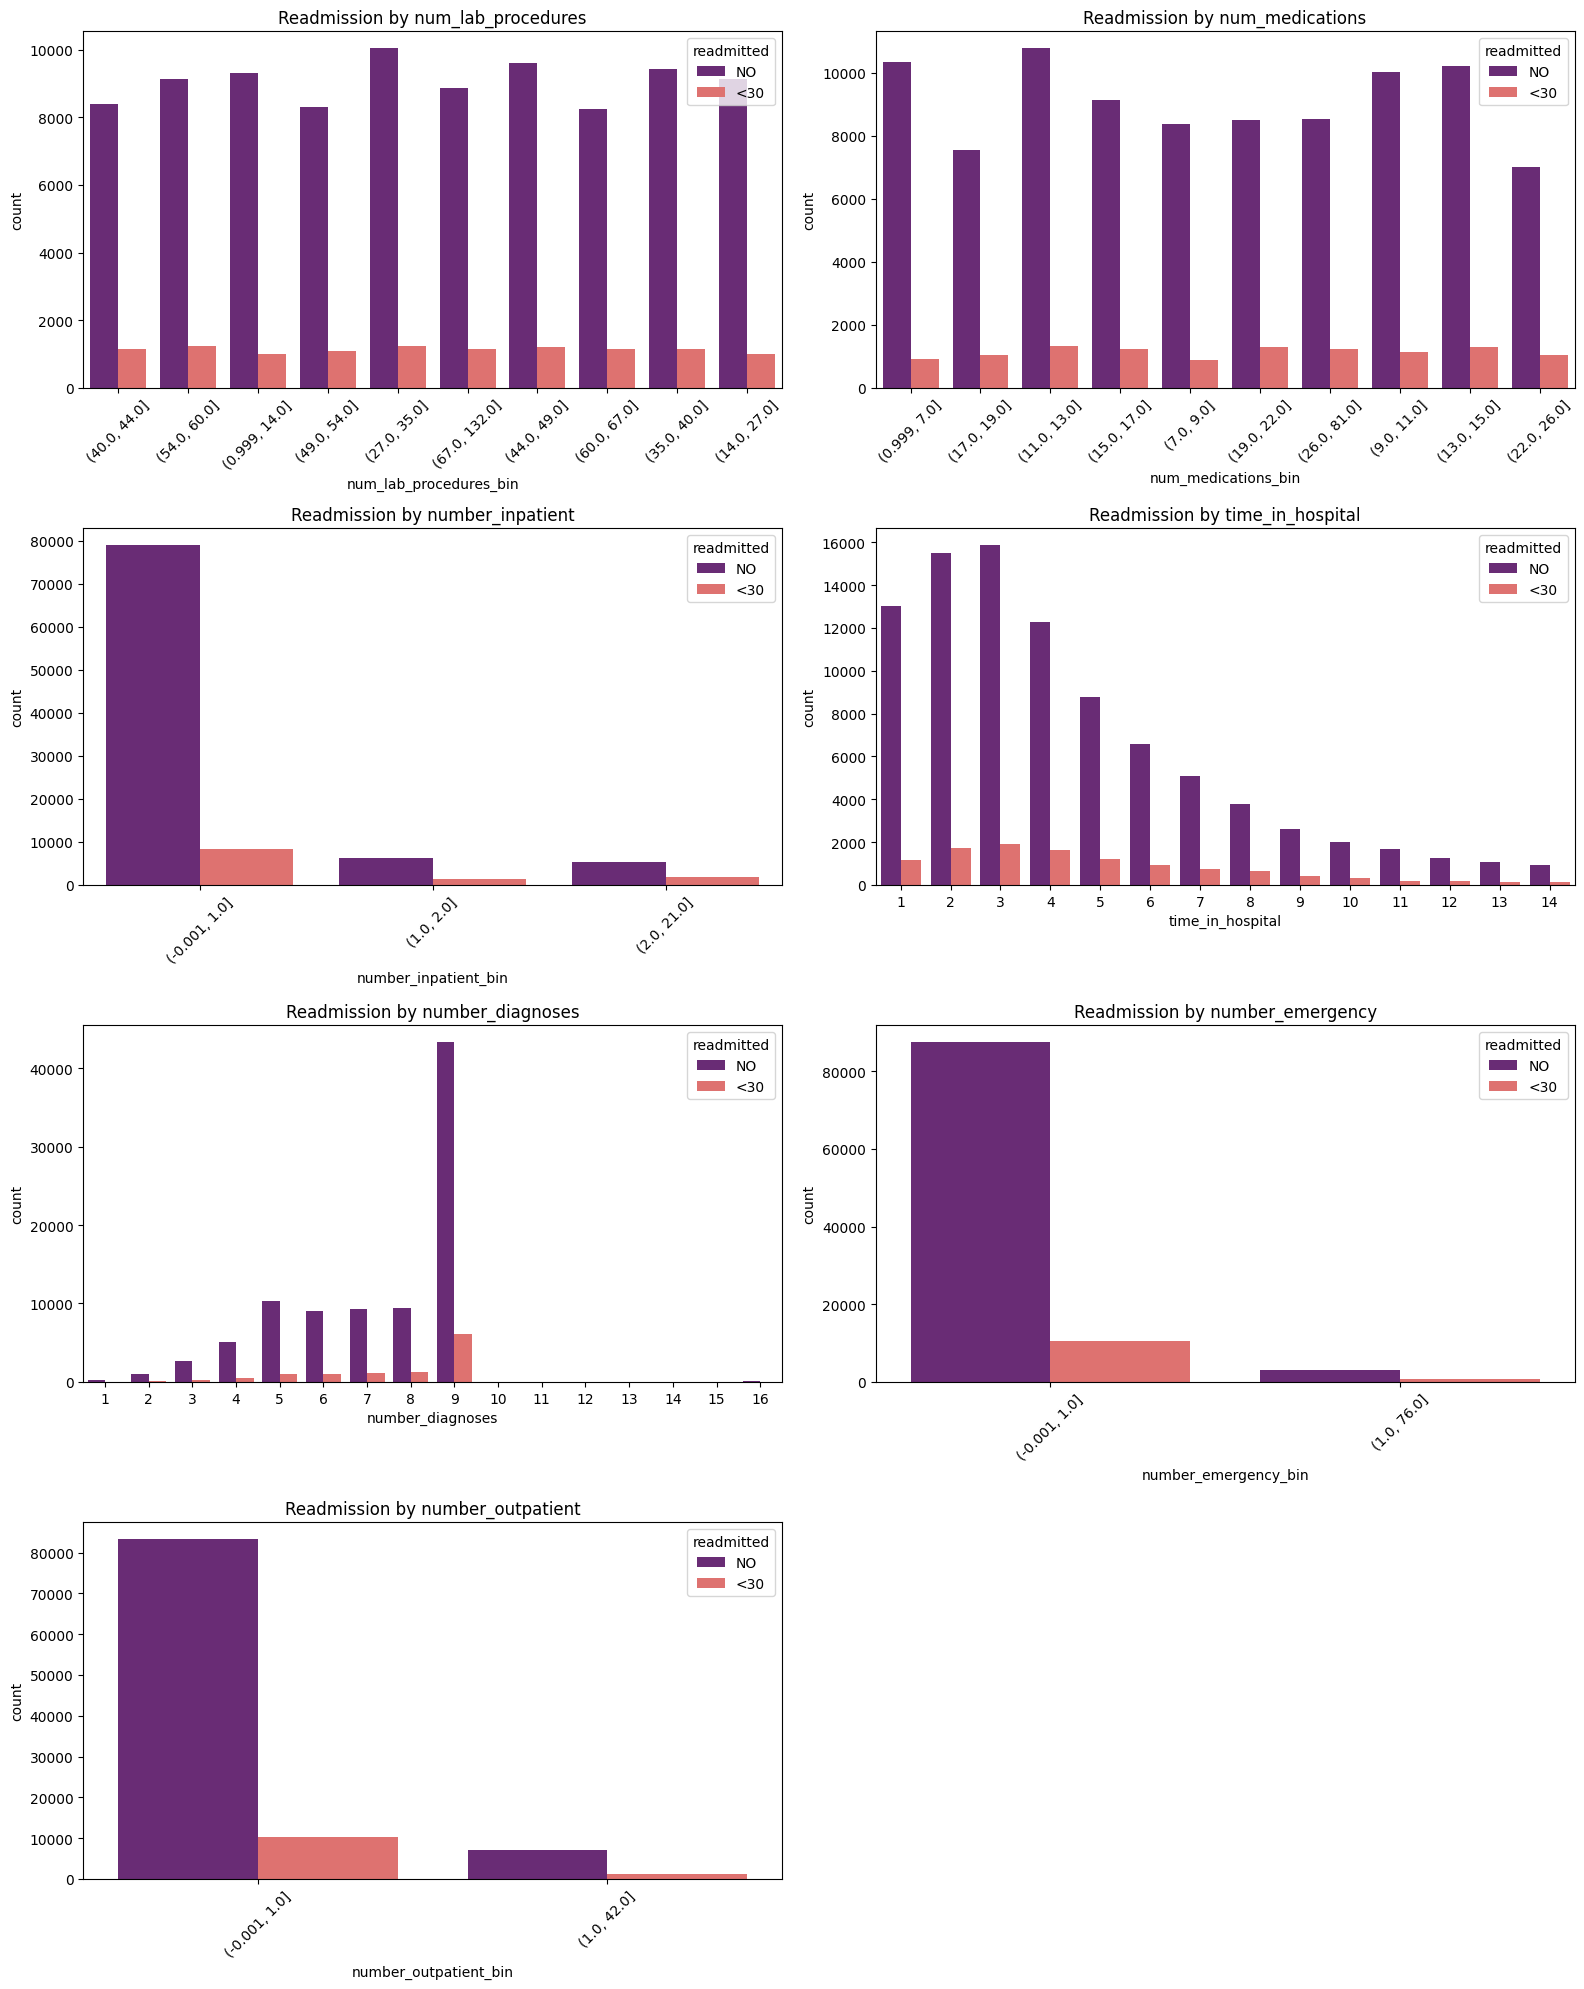

In [54]:
# --- EDA: Readmission by Clinical Metrics ---
metrics = ['num_lab_procedures', 'num_medications', 'number_inpatient', 'time_in_hospital', 'number_diagnoses', 'number_emergency', 'number_outpatient']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(metrics):
    if df[col].nunique() > 20:
        temp_df = df.copy()
        temp_df[f'{col}_bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop').astype(str)
        sns.countplot(data=temp_df, x=f'{col}_bin', hue='readmitted', ax=axes[i], palette='magma')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        sns.countplot(data=df, x=col, hue='readmitted', ax=axes[i], palette='magma')
    axes[i].set_title(f'Readmission by {col}')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

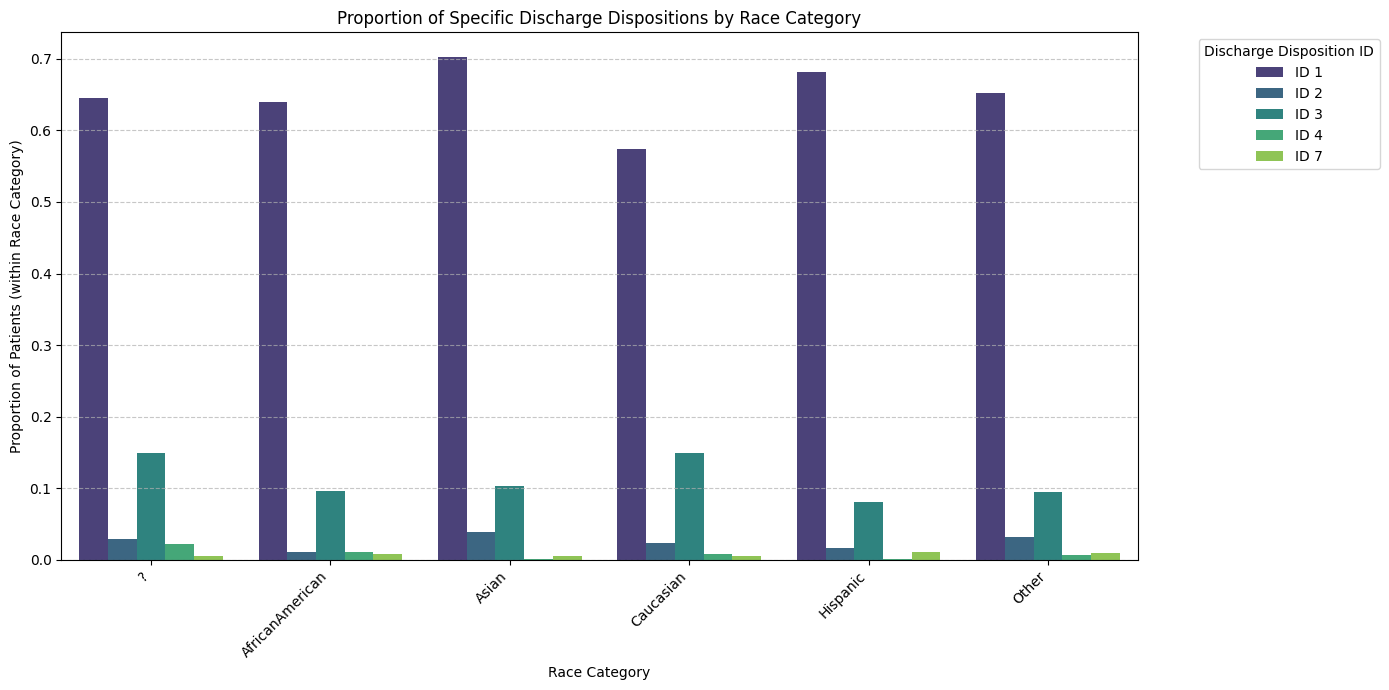

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify Target IDs
target_discharge_ids = [1, 2, 3, 4, 7]

# 2. Check if one-hot encoding is needed
# If 'race' column exists, create dummies. Otherwise, find existing dummy cols.
if 'race' in df.columns:
    race_dummies = pd.get_dummies(df['race'], prefix='race')
    temp_df = pd.concat([df, race_dummies], axis=1)
    race_cols = list(race_dummies.columns)
else:
    race_cols = [col for col in df.columns if col.startswith('race_')]
    temp_df = df.copy()

if 'discharge_disposition_id' in df.columns:
    discharge_dummies = pd.get_dummies(df['discharge_disposition_id'], prefix='discharge_disposition_id')
    temp_df = pd.concat([temp_df, discharge_dummies], axis=1)
    # Select only the specific columns requested by the user
    plot_discharge_cols = [f'discharge_disposition_id_{idx}' for idx in target_discharge_ids if f'discharge_disposition_id_{idx}' in temp_df.columns]
else:
    plot_discharge_cols = [col for col in temp_df.columns if any(col == f'discharge_disposition_id_{idx}' for idx in target_discharge_ids)]

# 3. Validation
if not race_cols or not plot_discharge_cols:
    print(f"Could not find required columns. Race columns found: {race_cols}")
    print(f"Discharge columns found: {plot_discharge_cols}")
else:
    # 4. Data Preparation
    data_for_plot = []
    for discharge_col in plot_discharge_cols:
        for race_col in race_cols:
            # Ensure columns are treated as numeric/boolean for calculation
            count_intersection = temp_df[(temp_df[race_col] > 0) & (temp_df[discharge_col] > 0)].shape[0]
            total_race = temp_df[temp_df[race_col] > 0].shape[0]
            proportion = count_intersection / total_race if total_race > 0 else 0

            data_for_plot.append({
                'Discharge Disposition': discharge_col.replace('discharge_disposition_id_', 'ID '),
                'Race': race_col.replace('race_', ''),
                'Proportion': proportion
            })

    plot_data = pd.DataFrame(data_for_plot)

    # 5. Plotting
    plt.figure(figsize=(14, 7))
    sns.barplot(
        data=plot_data,
        x='Race',
        y='Proportion',
        hue='Discharge Disposition',
        palette='viridis'
    )
    plt.title('Proportion of Specific Discharge Dispositions by Race Category')
    plt.xlabel('Race Category')
    plt.ylabel('Proportion of Patients (within Race Category)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Discharge Disposition ID', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

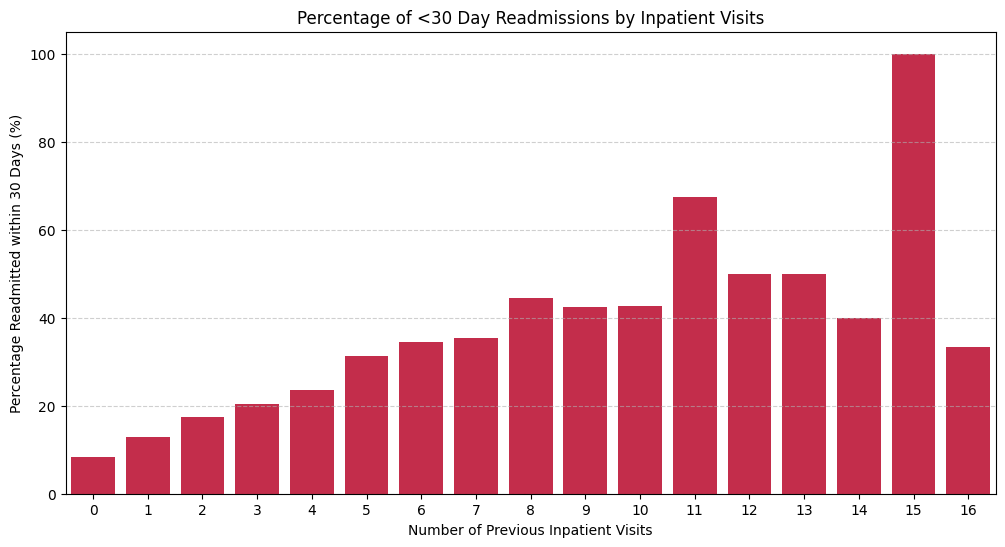

readmitted,number_inpatient,Total,Percent_<30
0,0,67630,8.437084
1,1,19521,12.924543
2,2,7566,17.433254
3,3,3411,20.287306
4,4,1622,23.612824
5,5,812,31.403941
6,6,480,34.583333
7,7,268,35.447761
8,8,151,44.370861
9,9,111,42.342342


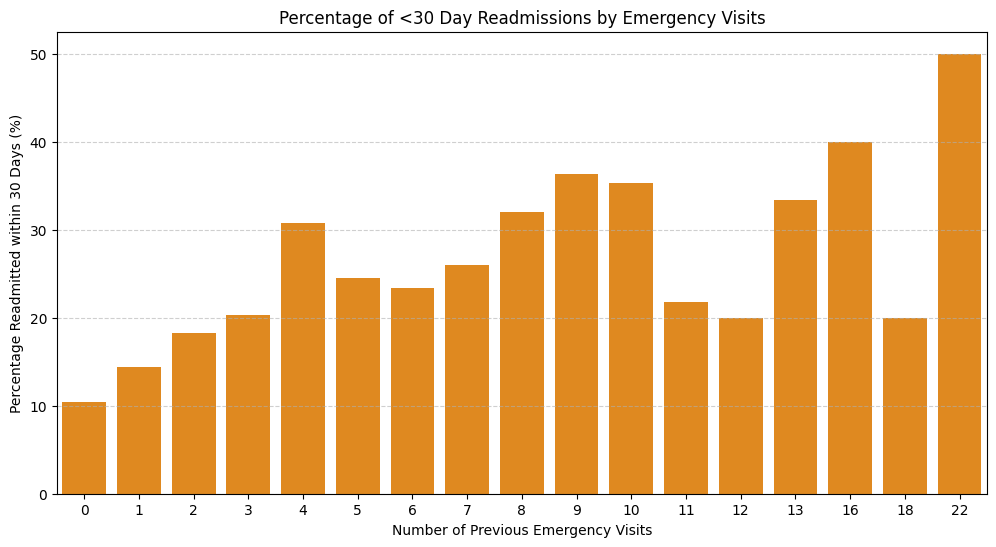

readmitted,number_emergency,Total,Percent_<30
0,0,90383,10.474315
1,1,7677,14.354566
2,2,2042,18.266405
3,3,725,20.275862
4,4,374,30.748663
5,5,192,24.479167
6,6,94,23.404255
7,7,73,26.027397
8,8,50,32.000000
9,9,33,36.363636


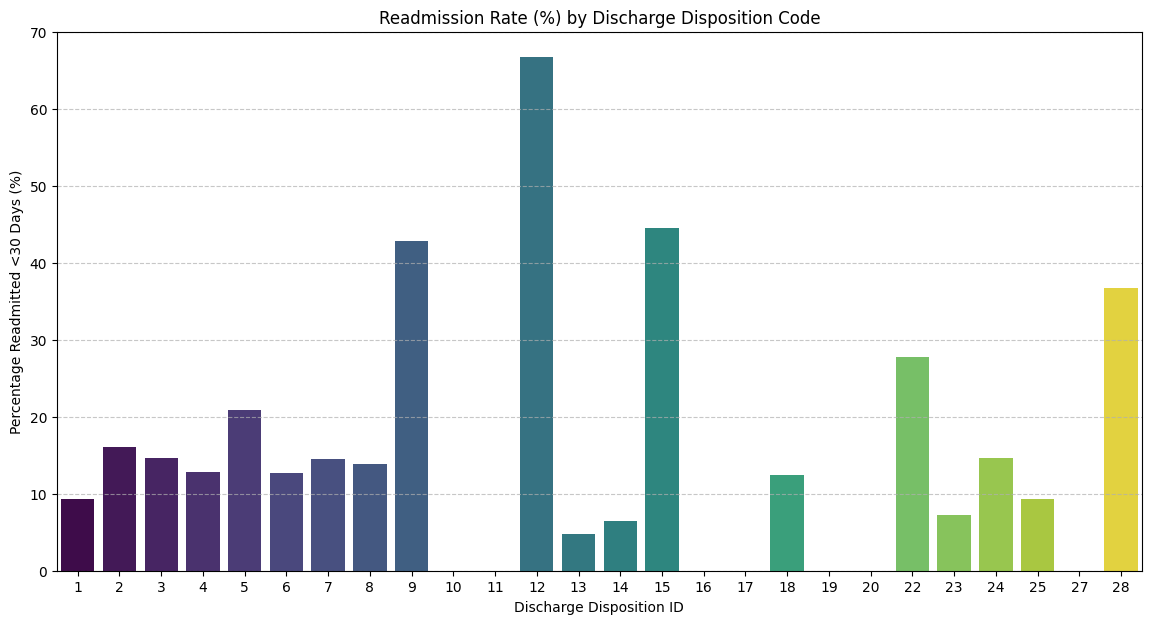

,discharge_disposition_id,Readmission_Rate
11,12,66.666667
14,15,44.444444
8,9,42.857143
25,28,36.690647
20,22,27.696939
4,5,20.861486
1,2,16.071429
2,3,14.662462
22,24,14.583333
6,7,14.446228


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA: Percentage of <30 Readmissions by Inpatient and Emergency Visits ---

def plot_readmission_percentage(df, column, color, title):
    # Calculate percentage of <30 readmissions per visit count
    # Note: Using 'df' directly as it contains the processed 'readmitted' column
    counts = df.groupby([column, 'readmitted']).size().unstack(fill_value=0)

    # Check if expected labels exist after filtering/processing
    target_label = '<30'
    no_label = 'NO'

    if target_label not in counts.columns:
        counts[target_label] = 0
    if no_label not in counts.columns:
        counts[no_label] = 0

    counts['Total'] = counts[target_label] + counts[no_label]

    # Filter to ensure we have at least 5 patients to make the percentage meaningful
    counts = counts[counts['Total'] >= 5].copy()
    counts['Percent_<30'] = (counts[target_label] / counts['Total']) * 100
    plot_data = counts.reset_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_data, x=column, y='Percent_<30', color=color)
    plt.title(title)
    plt.xlabel(f'Number of Previous {column.replace("number_", "").capitalize()} Visits')
    plt.ylabel('Percentage Readmitted within 30 Days (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    display(plot_data[[column, 'Total', 'Percent_<30']].head(10))

# Using 'df' which is defined in the kernel
plot_readmission_percentage(df, 'number_inpatient', 'crimson', 'Percentage of <30 Day Readmissions by Inpatient Visits')
plot_readmission_percentage(df, 'number_emergency', 'darkorange', 'Percentage of <30 Day Readmissions by Emergency Visits')

# --- Discharge Code Analysis ---

# Calculate readmission rate per discharge disposition
# Using df_text for original IDs before one-hot encoding
discharge_readmission = df.groupby('discharge_disposition_id')['readmitted'].apply(lambda x: (x == '<30').mean() * 100).reset_index()
discharge_readmission.columns = ['discharge_disposition_id', 'Readmission_Rate'] # Fixed typo here

# Sort for better visualization
discharge_readmission = discharge_readmission.sort_values('Readmission_Rate', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=discharge_readmission, x='discharge_disposition_id', y='Readmission_Rate', palette='viridis', hue='discharge_disposition_id', legend=False)

plt.title('Readmission Rate (%) by Discharge Disposition Code')
plt.xlabel('Discharge Disposition ID')
plt.ylabel('Percentage Readmitted <30 Days (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(discharge_readmission)

In [57]:
# Calculate total counts for specific discharge disposition codes
count_12 = df[df['discharge_disposition_id'] == 12].shape[0]
count_15 = df[df['discharge_disposition_id'] == 15].shape[0]

print(f"Total observations with Discharge Code 12: {count_12}")
print(f"Total observations with Discharge Code 15: {count_15}")

Total observations with Discharge Code 12: 3
Total observations with Discharge Code 15: 63


In [58]:
# Define the IDs to remove
ids_to_remove = [12, 15]

# Filter df_text (original categorical values)
original_count = df.shape[0]
df = df[~df['discharge_disposition_id'].isin(ids_to_remove)]

# Filter df (one-hot encoded values)
# Since discharge_disposition_id was dropped during one-hot encoding, we filter by the dummy columns
# We check if the columns exist before filtering to avoid errors
original_df_count = df.shape[0]

for val in ids_to_remove:
    col_name = f'discharge_disposition_id_{val}'
    if col_name in df.columns:
        df = df[df[col_name] == 0]

print(f"Removed {original_count - df.shape[0]} rows from df.")
print(f"Removed {original_df_count - df.shape[0]} rows from df.")
print(f"New dataset shape: {df.shape}")

Removed 66 rows from df.
Removed 0 rows from df.
New dataset shape: (101700, 47)


In [59]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,?,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,NO
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


simple logistic regression for analysis (taken from Quant Proj)


In [60]:
# @title

#load packages sklearn, pandas, numpy, matlab
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Plotting
import matplotlib.pyplot as plt

#load data
raw_data = df
raw_data.head()
display(raw_data.dtypes)
display(raw_data["A1Cresult"].head(50))
display(raw_data["max_glu_serum"].head(50))
display(raw_data["A1Cresult"].unique())
display(raw_data["max_glu_serum"].unique())
display(raw_data.dtypes)


encounter_id                 int64
patient_nbr                  int64
race                           str
gender                         str
age                            str
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                     str
medical_specialty              str
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                         str
diag_2                         str
diag_3                         str
number_diagnoses             int64
max_glu_serum               string
A1Cresult                   string
metformin                      str
repaglinide                    str
nateglinide                    str
chlorpropamide                 str
glimepiride                    str
acetohexamide       

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10    None
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
20    None
21    None
22    None
23    None
24    None
25    None
26      >7
27    None
28    None
29    None
30    None
31    None
32    None
33    None
34    None
35    None
36    None
37    None
38    None
39    None
40    None
41    None
42    None
43    None
44    None
45    None
46    None
47    None
48    None
49    None
Name: A1Cresult, dtype: string

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10    None
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
20    None
21    None
22    None
23    None
24    None
25    None
26    None
27    None
28    None
29    None
30    None
31    None
32    None
33    None
34    None
35    None
36    None
37    None
38    None
39    None
40    None
41    None
42    None
43    None
44    None
45    None
46    None
47    None
48    None
49    None
Name: max_glu_serum, dtype: string

<ArrowStringArray>
['None', '>7', '>8', 'Norm']
Length: 4, dtype: string

<ArrowStringArray>
['None', '>300', 'Norm', '>200']
Length: 4, dtype: string

encounter_id                 int64
patient_nbr                  int64
race                           str
gender                         str
age                            str
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                     str
medical_specialty              str
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                         str
diag_2                         str
diag_3                         str
number_diagnoses             int64
max_glu_serum               string
A1Cresult                   string
metformin                      str
repaglinide                    str
nateglinide                    str
chlorpropamide                 str
glimepiride                    str
acetohexamide       

In [61]:
# @title
cat_cols = [
    'race', 'gender', 'age', 'payer_code', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone',
    'change', 'diabetesMed', 'diag_1', 'diag_2', 'diag_3',
]

for col in cat_cols:
    # Check if the column still exists in df before attempting to get dummies
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(columns=[col])
    else:
        print(f"Warning: Column '{col}' not found in DataFrame 'df'. Skipping one-hot encoding.")

In [62]:
ID_COL = "patient_nbr"
LABEL_COL = "readmitted"

FEATURE_COLS = [col for col in df.columns if col not in [ID_COL, LABEL_COL]]
print(f"Updated FEATURE_COLS with {len(FEATURE_COLS)} features.")
# Display some of the new feature columns for verification
print(FEATURE_COLS[:5])
print(FEATURE_COLS[-5:])

Updated FEATURE_COLS with 2505 features.
['encounter_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications']
['diag_3_V70', 'diag_3_V72', 'diag_3_V85', 'diag_3_V86', 'diag_3_none']


In [63]:
# @title
#Encoding
for index, row in df.iterrows():
    print(row)
    break

encounter_id          2278392
patient_nbr           8222157
time_in_hospital            1
num_lab_procedures         41
num_procedures              0
                       ...   
diag_3_V70              False
diag_3_V72              False
diag_3_V85              False
diag_3_V86              False
diag_3_none              True
Name: 0, Length: 2507, dtype: object


In [64]:
#logistic regression
#make sure only binary 30 day or no is being predicted.
from sklearn.linear_model import LogisticRegressionCV

my_model = LogisticRegressionCV(
    cv=5,
    max_iter=500,
    scoring="accuracy",
    solver="lbfgs",
    class_weight='balanced'
)

# Define X and y for the initial model training
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

my_model.fit(X, y)

print("Initial Logistic Regression model trained.")

display(my_model.score(X,y))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

Initial Logistic Regression model trained.


0.5700589970501475

In [65]:
# Get feature importances (coefficients) from the logistic regression model
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': my_model.coef_[0] # Assuming binary classification, get the first class's coefficients
})

# Sort by absolute coefficient value to see most important features
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

print("\nTop 10 most important features (by absolute coefficient value):")
display(feature_importance.head(10))

print("\nTop 10 least important features (by absolute coefficient value):")
display(feature_importance.tail(10))


Top 10 most important features (by absolute coefficient value):


,feature,coefficient,abs_coefficient
1,patient_nbr,-1.377121e-09,1.377121e-09
0,encounter_id,4.746396e-10,4.746396e-10
3,num_lab_procedures,-1.132128e-14,1.132128e-14
5,num_medications,-8.940684e-15,8.940684e-15
8,number_inpatient,-5.564148e-15,5.564148e-15
2,time_in_hospital,-3.584243e-15,3.584243e-15
9,number_diagnoses,-2.776441e-15,2.776441e-15
7,number_emergency,-1.527505e-15,1.527505e-15
55,discharge_disposition_id_1,8.655452e-16,8.655452e-16
6,number_outpatient,-6.594088e-16,6.594088e-16



Top 10 least important features (by absolute coefficient value):


,feature,coefficient,abs_coefficient
1717,diag_3_110,1.939035e-20,1.939035e-20
308,diag_1_201,-1.860256e-20,1.860256e-20
1437,diag_2_714,-1.449352e-20,1.449352e-20
1846,diag_3_266,-1.405905e-20,1.405905e-20
597,diag_1_516,1.308622e-20,1.308622e-20
1988,diag_3_432,1.163991e-20,1.163991e-20
1354,diag_2_586,9.004961e-21,9.004961e-21
1946,diag_3_380,-4.200389e-21,4.200389e-21
1320,diag_2_54,-1.669622e-21,1.669622e-21
354,diag_1_250.21,1.091410e-21,1.091410e-21


In [66]:
# @title
#full feature list with coefs as an excel output
#feature_importance.to_excel('/content/drive/MyDrive/feature_importance.xlsx', index=False)

In [67]:
#take top 25 most impactful features
top_25_features = feature_importance.head(25)
#rerun logistic regression with top 25 features
X = df[top_25_features['feature']]
y = df["readmitted"]

# my_model.fit(X, y) # This fit is not needed here as we will refit in the next cell after splitting

print("Top 25 features selected.")

Top 25 features selected.


In [68]:
#refining varaible based on model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np # Ensure numpy is imported for np.where

# Define X and y using the top 25 features
X_top25 = df[top_25_features['feature']]
y_top25 = df["readmitted"]

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_top25, y_top25, test_size=0.2, random_state=42, stratify=y_top25
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

#my model with 25 top features
my_model.fit(X_train, y_train)

print("Logistic Regression model re-trained with top 25 features on training data.")

display(my_model.score(X,y))
#output the coefficients fo the top 25

X_train shape: (81360, 25)
X_test shape: (20340, 25)
y_train shape: (81360,)
y_test shape: (20340,)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

Logistic Regression model re-trained with top 25 features on training data.


0.39129793510324484

In [69]:
display(my_model.score(X,y)) #removing the deceased patients and rerunning with top 25 has helped improve accuracy.

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': my_model.coef_[0] # Assuming binary classification, get the first class's coefficients
})

# Sort by absolute coefficient value to see most important features
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

print("\nTop 10 most important features (by absolute coefficient value):")
display(feature_importance.head(25))

0.39129793510324484


Top 10 most important features (by absolute coefficient value):


,feature,coefficient,abs_coefficient
2,num_lab_procedures,-2.014980e-03,2.014980e-03
3,num_medications,-1.566805e-03,1.566805e-03
4,number_inpatient,-9.716129e-04,9.716129e-04
5,time_in_hospital,-6.310838e-04,6.310838e-04
6,number_diagnoses,-5.081679e-04,5.081679e-04
7,number_emergency,-2.529353e-04,2.529353e-04
8,discharge_disposition_id_1,1.559239e-04,1.559239e-04
9,number_outpatient,-1.132934e-04,1.132934e-04
11,insulin_No,7.578281e-05,7.578281e-05
12,discharge_disposition_id_3,-7.495313e-05,7.495313e-05


### Logistic Regression with Custom Feature Set

Based on your request, I will now train and evaluate a new logistic regression model using the specified list of features. The model will be trained with balanced class weights to address potential class imbalance, similar to previous logistic regression models.

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegressionCV
import numpy as np

# Define the new list of features based on the user's request
final_feature_list = [
    'num_procedures', 'time_in_hospital', 'number_inpatient',
    'number_outpatient', 'number_emergency', 'num_lab_procedures',
    'number_diagnoses', 'num_medications',
    "insulin_Up",
    "insulin_Steady",
    "insulin_No",
    "insulin_Down",
    "max_glu_serum_Norm",
    "max_glu_serum_None",
    "max_glu_serum_>300",
    "max_glu_serum_>200",
    "gender_Unknown/Invalid",
    "A1Cresult_Norm",
    "A1Cresult_None",
    "A1Cresult_>8",
    "A1Cresult_>7",
    'age_[0-10)', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)',
    'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)',
    'gender_Female', 'gender_Male', 'race_Asian', 'race_Caucasian', 'race_AfricanAmerican',
    'race_Hispanic', 'race_Other', 'race_Unknown',
    'discharge_disposition_id_1', 'discharge_disposition_id_2',
    'discharge_disposition_id_3',
    'discharge_disposition_id_4', 'discharge_disposition_id_5',
    'discharge_disposition_id_6',
    'discharge_disposition_id_7', 'discharge_disposition_id_8',
    'discharge_disposition_id_9',
    'discharge_disposition_id_10',
    'discharge_disposition_id_13', 'discharge_disposition_id_14',
    'discharge_disposition_id_16', 'discharge_disposition_id_17',
    'discharge_disposition_id_18', 'discharge_disposition_id_22',
    'discharge_disposition_id_23',
    'discharge_disposition_id_24', 'discharge_disposition_id_25',
    'discharge_disposition_id_26',
    'discharge_disposition_id_27', 'discharge_disposition_id_28',
    'change_No', 'change_Ch',

]

# Filter out any features that might not exist in the DataFrame
# This can happen if, for example, a category wasn't present in the original data
# or if the one-hot encoding resulted in slightly different names.
existing_new_features = [col for col in final_feature_list if col in df.columns]
missing_features = [col for col in final_feature_list if col not in df.columns]

if missing_features:
    print(f"Warning: The following requested features were not found in the DataFrame and will be skipped: {missing_features}")

# Define X and y using the updated feature set
X_custom_features = df[existing_new_features]
y_custom_features = df[LABEL_COL]

# Perform 80/20 train-test split
X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom_features, y_custom_features, test_size=0.2, random_state=42, stratify=y_custom_features
)

print(f"X_train_custom shape: {X_train_custom.shape}")
print(f"X_test_custom shape: {X_test_custom.shape}")
print(f"y_train_custom shape: {y_train_custom.shape}")
print(f"y_test_custom shape: {y_test_custom.shape}")

# Initialize and train the logistic regression model with balanced class weights
custom_model = LogisticRegressionCV(
    cv=5,
    max_iter=500,
    scoring="accuracy",
    solver="lbfgs",
    class_weight='balanced' # Keeping balanced class weight as in previous models
)

custom_model.fit(X_train_custom, y_train_custom)

print("\nLogistic Regression model re-trained with custom feature set on training data.")

# Evaluate the custom model on the hold-out test set
y_pred_test_custom = custom_model.predict(X_test_custom)
accuracy_test_custom = accuracy_score(y_test_custom, y_pred_test_custom)
f1_test_custom = f1_score(y_test_custom, y_pred_test_custom, pos_label='<30')

# Get probabilities for AUC calculation
y_pred_proba_test_custom = custom_model.predict_proba(X_test_custom)

# Find the index of the positive class ('<30') in custom_model.classes_
pos_class_idx_custom = np.where(custom_model.classes_ == '<30')[0][0]

# Convert y_test_custom to numerical labels for AUC calculation
y_test_numeric_for_auc_custom = y_test_custom.apply(lambda x: 1 if x == '<30' else 0)

# Calculate AUC
auc_test_custom = roc_auc_score(y_test_numeric_for_auc_custom, y_pred_proba_test_custom[:, pos_class_idx_custom])

print(f"\nCustom Model accuracy on the 20% hold-out test set: {accuracy_test_custom:.4f}")
print(f"Custom Model F1 Score on the 20% hold-out test set: {f1_test_custom:.4f}")
print(f"Custom Model AUC on the 20% hold-out test set: {auc_test_custom:.4f}")

print("\nClassification Report for Custom Feature Set Model on Test Set:")
print(classification_report(y_test_custom, y_pred_test_custom, target_names=custom_model.classes_, zero_division=0))

X_train_custom shape: (81360, 61)
X_test_custom shape: (20340, 61)
y_train_custom shape: (81360,)
y_test_custom shape: (20340,)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details


Logistic Regression model re-trained with custom feature set on training data.

Custom Model accuracy on the 20% hold-out test set: 0.6790
Custom Model F1 Score on the 20% hold-out test set: 0.2749
Custom Model AUC on the 20% hold-out test set: 0.6676

Classification Report for Custom Feature Set Model on Test Set:
              precision    recall  f1-score   support

         <30       0.18      0.55      0.27      2265
          NO       0.92      0.70      0.79     18075

    accuracy                           0.68     20340
   macro avg       0.55      0.62      0.53     20340
weighted avg       0.84      0.68      0.74     20340



### XGBoost Model with Custom Feature Set

Now, let's train an XGBoost model using the same `final_feature_list` to predict readmission. XGBoost is a powerful gradient boosting algorithm that often performs well on tabular data.

In [71]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix
import numpy as np
import re
import pandas as pd

# Filter out any features that might not exist in the DataFrame
existing_xgb_features = [col for col in final_feature_list if col in df.columns]

X_xgb = df[existing_xgb_features]
y_xgb = df[LABEL_COL]

# Sanitize column names for XGBoost
def sanitize_colnames(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_xgb = sanitize_colnames(X_xgb)

# Convert target labels to numerical format (0 and 1) for XGBoost
y_xgb_numeric = y_xgb.map({'NO': 0, '<30': 1})

# Perform 80/20 train-test split, stratifying on the numerical target
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb_numeric, test_size=0.2, random_state=42, stratify=y_xgb_numeric
)

# Initialize and train the XGBoost classifier with class imbalance handling
positive_count = y_train_xgb.sum()
negative_count = len(y_train_xgb) - positive_count
scale_pos_weight_val = negative_count / positive_count

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_val
)

xgb_model.fit(X_train_xgb, y_train_xgb)

print("XGBoost model trained with custom feature set.")

# Evaluate the XGBoost model
y_pred_test_xgb = xgb_model.predict(X_test_xgb)
accuracy_test_xgb = accuracy_score(y_test_xgb, y_pred_test_xgb)
f1_test_xgb = f1_score(y_test_xgb, y_pred_test_xgb)
y_pred_proba_test_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
auc_test_xgb = roc_auc_score(y_test_xgb, y_pred_proba_test_xgb)

print(f"\nAccuracy: {accuracy_test_xgb:.4f}")
print(f"F1 Score: {f1_test_xgb:.4f}")
print(f"AUC: {auc_test_xgb:.4f}")

# Generate and display Confusion Matrix
cm = confusion_matrix(y_test_xgb, y_pred_test_xgb)
cm_df = pd.DataFrame(
    cm,
    index=['Actual NO', 'Actual <30'],
    columns=['Predicted NO', 'Predicted <30']
)

print("\nConfusion Matrix:")
display(cm_df)

print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_test_xgb, target_names=['NO', '<30'], zero_division=0))

XGBoost model trained with custom feature set.

Accuracy: 0.6657
F1 Score: 0.2771
AUC: 0.6726

Confusion Matrix:


,Predicted NO,Predicted <30
Actual NO,12238,5837
Actual <30,962,1303



Classification Report:
              precision    recall  f1-score   support

          NO       0.93      0.68      0.78     18075
         <30       0.18      0.58      0.28      2265

    accuracy                           0.67     20340
   macro avg       0.55      0.63      0.53     20340
weighted avg       0.84      0.67      0.73     20340



### Fine-tuning XGBoost Model

Now, let's create a function to encapsulate the training and evaluation of the XGBoost model using the same `final_feature_list` and apply the class weights.

In [72]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import numpy as np
import re

def train_xgboost_model(X_train, X_test, y_train, y_test, class_weights):
    # Sanitize column names for XGBoost
    def sanitize_colnames(df):
        cols = df.columns
        new_cols = []
        for col in cols:
            new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col) # Replace [, ], < with _
            new_cols.append(new_col)
        df.columns = new_cols
        return df

    X_train_sanitized = sanitize_colnames(X_train.copy())
    X_test_sanitized = sanitize_colnames(X_test.copy())

    # Convert target labels to numerical format (0 and 1) for XGBoost
    y_train_numeric = y_train.map({'NO': 0, '<30': 1})
    y_test_numeric = y_test.map({'NO': 0, '<30': 1})

    # Calculate scale_pos_weight from class_weights. We assume class_weights['<30'] / class_weights['NO']
    if 'NO' in class_weights and '<30' in class_weights and class_weights['NO'] != 0:
        scale_pos_weight_val = class_weights['<30'] / class_weights['NO']
    else:
        # Fallback to default if weights are not properly defined or NO is zero
        positive_count = y_train_numeric.sum()
        negative_count = len(y_train_numeric) - positive_count
        scale_pos_weight_val = negative_count / positive_count if positive_count > 0 else 1

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False, # Suppress warning
        random_state=42,
        n_estimators=100, # Number of boosting rounds
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight_val # Apply class imbalance handling
    )

    xgb_model.fit(X_train_sanitized, y_train_numeric)

    print("\nXGBoost model trained with custom feature set on training data.")

    # Evaluate the XGBoost model on the hold-out test set
    y_pred_test_xgb = xgb_model.predict(X_test_sanitized)
    accuracy_test_xgb = accuracy_score(y_test_numeric, y_pred_test_xgb)
    f1_test_xgb = f1_score(y_test_numeric, y_pred_test_xgb)

    # Get probabilities for AUC calculation
    y_pred_proba_test_xgb = xgb_model.predict_proba(X_test_sanitized)[:, 1] # Probability of the positive class (1)
    auc_test_xgb = roc_auc_score(y_test_numeric, y_pred_proba_test_xgb)

    print(f"\nXGBoost Model accuracy on the 20% hold-out test set: {accuracy_test_xgb:.4f}")
    print(f"XGBoost Model F1 Score on the 20% hold-out test set: {f1_test_xgb:.4f}")
    print(f"XGBoost Model AUC on the 20% hold-out test set: {auc_test_xgb:.4f}")

    print("\nClassification Report for XGBoost Model on Test Set:")
    print(classification_report(y_test_numeric, y_pred_test_xgb, target_names=['NO', '<30'], zero_division=0))

    return xgb_model, accuracy_test_xgb, f1_test_xgb, auc_test_xgb, y_pred_test_xgb, y_test_numeric

In [73]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Verification of feature set usage
print(f"Verifying feature set: Using {X_train_custom.shape[1]} features from the custom set.")

# 2. Run the XGBoost model training (as currently in the cell)
class_weights_xgb = {'NO': 3, '<30': 15}
xgb_model, xgb_accuracy, xgb_f1, xgb_auc, y_pred_test_xgb, y_test_numeric = train_xgboost_model(
    X_train=X_train_custom,
    X_test=X_test_custom,
    y_train=y_train_custom,
    y_test=y_test_custom,
    class_weights=class_weights_xgb
)

# 3. Output 'Coefficients' and 'P-values' using a weighted Logit model
# XGBoost doesn't provide p-values, so we use statsmodels on the same data/weights
print("\n--- Generating Coefficients and P-values via Weighted Logistic Regression ---")

# Prepare data for statsmodels
X_sm = X_train_custom.copy()

# Convert Boolean columns to integers
for col in X_sm.select_dtypes(include="bool").columns:
    X_sm[col] = X_sm[col].astype(int)

# Ensure all predictors are numeric and finite
X_sm = X_sm.apply(pd.to_numeric, errors="coerce")
X_sm = X_sm.replace([np.inf, -np.inf], np.nan).fillna(0)

# Remove constant columns that can cause singularity
X_sm = X_sm.loc[:, X_sm.nunique() > 1]
X_sm = sm.add_constant(X_sm, has_constant="add")

# Encode target
y_sm = y_train_custom.map({"NO": 0, "<30": 1}).astype(float)

# Correct class-weight mapping: target values are 0 and 1
sample_weights = y_sm.map({0: 3, 1: 15}).astype(float)

try:
    glm_model = sm.GLM(
        y_sm,
        X_sm,
        family=sm.families.Binomial(),
        freq_weights=sample_weights
    )

    glm_results = glm_model.fit(maxiter=200)

    summary_df = pd.DataFrame({
        "Coefficient": glm_results.params,
        "P-value": glm_results.pvalues
    }).sort_values("P-value")

    print("\nStatistical Summary (Top 20 most significant features):")
    display(summary_df.head(20))

except Exception as e:
    print(f"Could not calculate statistical summary: {e}")


Verifying feature set: Using 61 features from the custom set.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [20:50:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost model trained with custom feature set on training data.

XGBoost Model accuracy on the 20% hold-out test set: 0.8198
XGBoost Model F1 Score on the 20% hold-out test set: 0.2630
XGBoost Model AUC on the 20% hold-out test set: 0.6624

Classification Report for XGBoost Model on Test Set:
              precision    recall  f1-score   support

          NO       0.91      0.89      0.90     18075
         <30       0.24      0.29      0.26      2265

    accuracy                           0.82     20340
   macro avg       0.58      0.59      0.58     20340
weighted avg       0.83      0.82      0.83     20340


--- Generating Coefficients and P-values via Weighted Logistic Regression ---


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)



Statistical Summary (Top 20 most significant features):


,Coefficient,P-value
const,4.603408e+19,0.0
gender_Male,-9.115712e+18,0.0
race_Asian,2.381902e+14,0.0
race_Caucasian,2.314580e+14,0.0
race_AfricanAmerican,2.715648e+14,0.0
race_Hispanic,1.095202e+14,0.0
race_Other,2.800678e+13,0.0
discharge_disposition_id_1,5.771186e+15,0.0
discharge_disposition_id_2,6.053619e+15,0.0
discharge_disposition_id_3,6.018018e+15,0.0


In [74]:
# Extract summary data from the previously fitted GLM results
if 'glm_results' in globals():
    summary_table = pd.DataFrame({
        'Coefficient': glm_results.params,
        'Std.Error': glm_results.bse,
        'z-value': glm_results.tvalues,
        'P-value': glm_results.pvalues
    })

    # Sort by P-value to show the most statistically significant features first
    summary_table = summary_table.sort_values('P-value')

    print("--- Full Statistical Summary (Coefficients & P-values) ---")
    display(summary_table)
else:
    print("Error: GLM model results not found in kernel memory. Please ensure cell 52286934 executed completely.")

--- Full Statistical Summary (Coefficients & P-values) ---


,Coefficient,Std.Error,z-value,P-value
const,4.603408e+19,9.921375e+11,4.639890e+07,0.0
gender_Male,-9.115712e+18,1.964629e+11,-4.639916e+07,0.0
race_Asian,2.381902e+14,1.636625e+06,1.455374e+08,0.0
race_Caucasian,2.314580e+14,8.074848e+05,2.866408e+08,0.0
race_AfricanAmerican,2.715648e+14,8.311306e+05,3.267414e+08,0.0
...,...,...,...,...
age_[40-50),-2.735155e+18,5.893886e+10,-4.640666e+07,0.0
age_[50-60),-2.735160e+18,5.893886e+10,-4.640674e+07,0.0
age_[60-70),-2.735319e+18,5.893886e+10,-4.640943e+07,0.0
max_glu_serum_>300,-6.838051e+18,1.473471e+11,-4.640776e+07,0.0


### Final Financial Comparison (Updated Costs)
**Assumptions:**
* Intervention Cost (TP/FP): **$3,000**
* Missed Readmission Cost (FN): **$15,000**

In [75]:
# Financial comparison using the same 20% hold-out set

from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import re

INTERVENTION_COST = 3_000
READMISSION_COST = 15_000

# Use the existing custom logistic model and consistent hold-out data
y_test_financial = y_test_custom.map({"NO": 0, "<30": 1}).astype(int)

# Sanitize XGBoost feature names without changing the original data
def sanitize_features(data):
    result = data.copy()
    result.columns = [
        re.sub(r"[^a-zA-Z0-9_]", "_", str(col))
        for col in result.columns
    ]
    return result

X_train_financial = sanitize_features(X_train_custom)
X_test_financial = sanitize_features(X_test_custom)

# Base XGBoost model
xgb_base_financial = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=1
)

xgb_base_financial.fit(
    X_train_financial,
    y_train_custom.map({"NO": 0, "<30": 1}).astype(int)
)

# Fine-tuned/weighted XGBoost model
xgb_tuned_financial = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=15 / 3
)

xgb_tuned_financial.fit(
    X_train_financial,
    y_train_custom.map({"NO": 0, "<30": 1}).astype(int)
)

# Predictions from all models on the identical test set
predictions = {
    "Base Logistic Regression": (
        custom_model.predict(X_test_custom) == "<30"
    ).astype(int),
    "Base XGBoost": xgb_base_financial.predict(X_test_financial).astype(int),
    "Fine-tuned XGBoost": xgb_tuned_financial.predict(X_test_financial).astype(int),
}

# No-intervention baseline
baseline_readmissions = int(y_test_financial.sum())
baseline_cost = baseline_readmissions * READMISSION_COST

# ...existing code...

def calculate_financial_impact(y_actual, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_actual, y_pred, labels=[0, 1]
    ).ravel()

    # FP and TP patients receive the intervention.
    intervention_count = fp + tp
    intervention_cost = intervention_count * INTERVENTION_COST

    # Only missed readmissions (FN) incur the $15,000 readmission cost.
    readmission_cost = fn * READMISSION_COST
    total_cost = intervention_cost + readmission_cost

    return {
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Interventions": intervention_count,
        "Actual Readmissions": int(y_actual.sum()),
        "Intervention Cost": intervention_cost,
        "Readmission Cost": readmission_cost,
        "Total Cost": total_cost,
        "Baseline Cost": baseline_cost,
        "Savings vs No Intervention": baseline_cost - total_cost,
        "ROI": (
            (baseline_cost - total_cost) / intervention_cost
            if intervention_cost > 0 else np.nan
        ),
    }

financial_results = pd.DataFrame([
    {
        "Model": model_name,
        **calculate_financial_impact(y_test_financial, prediction)
    }
    for model_name, prediction in predictions.items()
])

# Add the no-intervention comparison
baseline_row = pd.DataFrame([{
    "Model": "No Intervention Baseline",
    "True Negatives": int((y_test_financial == 0).sum()),
    "False Positives": 0,
    "False Negatives": baseline_readmissions,
    "True Positives": 0,
    "Interventions": 0,
    "Actual Readmissions": baseline_readmissions,
    "Intervention Cost": 0,
    "Readmission Cost": baseline_cost,
    "Total Cost": baseline_cost,
    "Baseline Cost": baseline_cost,
    "Savings vs No Intervention": 0,
    "ROI": np.nan,
}])

financial_results = pd.concat(
    [baseline_row, financial_results],
    ignore_index=True
)

currency_columns = [
    "Intervention Cost",
    "Readmission Cost",
    "Total Cost",
    "Baseline Cost",
    "Savings vs No Intervention",
]


# --------------------------------------------------------------------
# Statistical validation for the financial impact
# We test whether the savings are materially different from zero
# rather than just random noise from the holdout sample.
# --------------------------------------------------------------------
from scipy import stats
import numpy as np

def patient_level_savings(y_actual, y_pred, intervention_cost=INTERVENTION_COST, readmission_cost=READMISSION_COST):
    y_actual = np.asarray(y_actual, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    baseline_cost_per_patient = y_actual * readmission_cost
    model_cost_per_patient = y_pred * intervention_cost + (1 - y_pred) * y_actual * readmission_cost
    savings_per_patient = baseline_cost_per_patient - model_cost_per_patient

    return savings_per_patient

def bootstrap_mean_ci(values, n_boot=2000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(values, dtype=float)

    boot_means = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means[i] = sample.mean()

    ci_low, ci_high = np.quantile(boot_means, [alpha / 2, 1 - alpha / 2])
    return {
        "mean": float(np.mean(values)),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
    }

def permutation_pvalue(values, n_perm=5000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(values, dtype=float)
    observed_mean = float(np.mean(values))

    null_means = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        signs = rng.choice([-1, 1], size=len(values))
        null_means[i] = np.mean(values * signs)

    p_value = float(np.mean(np.abs(null_means) >= abs(observed_mean)))
    return p_value

stat_rows = []

for model_name, model_pred in predictions.items():
    model_pred = np.asarray(model_pred, dtype=int)
    savings = patient_level_savings(y_test_financial, model_pred)

    ci = bootstrap_mean_ci(savings)
    p_perm = permutation_pvalue(savings)
    t_stat, p_t = stats.ttest_1samp(savings, popmean=0)

    stat_rows.append({
        "Model": model_name,
        "Mean Savings / Patient": ci["mean"],
        "95% CI Low": ci["ci_low"],
        "95% CI High": ci["ci_high"],
        "Permutation P-value": p_perm,
        "One-sample t-test P-value": p_t,
        "t-statistic": t_stat,
        "Total Savings": float(savings.sum()),
    })

stat_summary = pd.DataFrame(stat_rows).sort_values("Total Savings", ascending=False)
display(stat_summary)

print("\nInterpretation:")
print("- If the 95% CI for mean savings does not cross 0, the savings are likely real.")
print("- If the permutation p-value < 0.05, the savings are unlikely to be random noise.")
print("- Compare models using average savings per patient and confidence intervals, not just total dollars.")


from IPython.display import Markdown, display

def money(x):
    if pd.isna(x):
        return "N/A"
    return f"${x:,.0f}"

def pct(x):
    if pd.isna(x):
        return "N/A"
    return f"{x:.2%}"

def markdown_table(df, value_formatters=None):
    if value_formatters is None:
        value_formatters = {}
    cols = list(df.columns)
    rows = []
    rows.append("| " + " | ".join(str(c) for c in cols) + " |")
    rows.append("| " + " | ".join(["---"] * len(cols)) + " |")

    for _, row in df.iterrows():
        vals = []
        for c in cols:
            v = row[c]
            if pd.isna(v):
                vals.append("—")
            elif c in value_formatters:
                vals.append(value_formatters[c](v))
            else:
                vals.append(str(v))
        rows.append("| " + " | ".join(vals) + " |")
    return "\n".join(rows)

# Build report-ready tables
financial_for_report = financial_results[financial_results["Model"] != "No Intervention Baseline"].copy()
financial_for_report["Intervention Cost"] = financial_for_report["Intervention Cost"].apply(lambda x: float(x))
financial_for_report["Readmission Cost"] = financial_for_report["Readmission Cost"].apply(lambda x: float(x))
financial_for_report["Total Cost"] = financial_for_report["Total Cost"].apply(lambda x: float(x))
financial_for_report["Savings vs No Intervention"] = financial_for_report["Savings vs No Intervention"].apply(lambda x: float(x))
financial_for_report["ROI"] = financial_for_report["ROI"].apply(lambda x: np.nan if pd.isna(x) else float(x))

sig_table = stat_summary[[
    "Model",
    "Mean Savings / Patient",
    "95% CI Low",
    "95% CI High",
    "Permutation P-value",
    "One-sample t-test P-value"
]].copy()

best_model = stat_summary.sort_values("Total Savings", ascending=False).iloc[0]
best_model_name = best_model["Model"]

best_financial = financial_for_report[financial_for_report["Model"] == best_model_name].iloc[0]
best_total_savings = best_financial["Savings vs No Intervention"]
best_mean_savings = best_model["Mean Savings / Patient"]
best_ci_low = best_model["95% CI Low"]
best_ci_high = best_model["95% CI High"]

report_md = f"""
# Readmission Prevention Financial Impact Report

## Executive Summary
- Test set size: {len(y_test_financial):,}
- Baseline readmissions: {baseline_readmissions:,}
- No-intervention baseline cost: {money(baseline_cost)}
- Best-performing model: **{best_model_name}**
- Estimated total savings vs no intervention: **{money(best_total_savings)}**
- Mean savings per patient: **{money(best_mean_savings)}**
- 95% confidence interval for mean savings per patient: **{money(best_ci_low)} to {money(best_ci_high)}**
- Permutation p-value: **{best_model['Permutation P-value']:.4f}**
- One-sample t-test p-value: **{best_model['One-sample t-test P-value']:.4f}**

## Financial Comparison
{markdown_table(
    financial_for_report[[
        "Model",
        "Intervention Cost",
        "Readmission Cost",
        "Total Cost",
        "Savings vs No Intervention",
        "ROI"
    ]].copy(),
    {
        "Intervention Cost": lambda x: money(x),
        "Readmission Cost": lambda x: money(x),
        "Total Cost": lambda x: money(x),
        "Savings vs No Intervention": lambda x: money(x),
        "ROI": lambda x: pct(x)
    }
)}

## Statistical Significance
{markdown_table(
    sig_table,
    {
        "Mean Savings / Patient": lambda x: money(x),
        "95% CI Low": lambda x: money(x),
        "95% CI High": lambda x: money(x),
        "Permutation P-value": lambda x: f"{x:.4f}",
        "One-sample t-test P-value": lambda x: f"{x:.4f}"
    }
)}

## Interpretation
- A 95% CI that does not include zero suggests the savings are unlikely to be random noise.
- A permutation p-value below 0.05 indicates the average savings are statistically significant.
- If the model shows both positive savings and a significant p-value, the intervention appears to produce real financial value.
"""

display(Markdown(report_md))

# Optional: save the report as a text file
with open("financial_report.md", "w") as f:
    f.write(report_md)


# --------------------------------------------------------------------
# Keep the existing financial table display below
# --------------------------------------------------------------------
display(
    financial_results.style.format({
        **{column: "${:,.0f}" for column in currency_columns},
        "ROI": "{:.2%}",
    })
)

print(f"Test-set size: {len(y_test_financial):,}")
print(f"Actual <30-day readmissions: {baseline_readmissions:,}")
print(f"No-intervention baseline cost: ${baseline_cost:,.0f}")

,Model,Mean Savings / Patient,95% CI Low,95% CI High,Permutation P-value,One-sample t-test P-value,t-statistic,Total Savings
2,Fine-tuned XGBoost,86.578171,55.309735,119.620206,0.0000,2.643408e-07,5.148984,1761000.0
1,Base XGBoost,14.896755,8.554572,21.533923,0.0000,9.236506e-06,4.435443,303000.0
0,Base Logistic Regression,-81.268437,-126.699853,-33.477139,0.0008,5.327260e-04,-3.464291,-1653000.0



Interpretation:
- If the 95% CI for mean savings does not cross 0, the savings are likely real.
- If the permutation p-value < 0.05, the savings are unlikely to be random noise.
- Compare models using average savings per patient and confidence intervals, not just total dollars.



# Readmission Prevention Financial Impact Report

## Executive Summary
- Test set size: 20,340
- Baseline readmissions: 2,265
- No-intervention baseline cost: $33,975,000
- Best-performing model: **Fine-tuned XGBoost**
- Estimated total savings vs no intervention: **$1,761,000**
- Mean savings per patient: **$87**
- 95% confidence interval for mean savings per patient: **$55 to $120**
- Permutation p-value: **0.0000**
- One-sample t-test p-value: **0.0000**

## Financial Comparison
| Model | Intervention Cost | Readmission Cost | Total Cost | Savings vs No Intervention | ROI |
| --- | --- | --- | --- | --- | --- |
| Base Logistic Regression | $20,223,000 | $15,405,000 | $35,628,000 | $-1,653,000 | -8.17% |
| Base XGBoost | $162,000 | $33,510,000 | $33,672,000 | $303,000 | 187.04% |
| Fine-tuned XGBoost | $8,439,000 | $23,775,000 | $32,214,000 | $1,761,000 | 20.87% |

## Statistical Significance
| Model | Mean Savings / Patient | 95% CI Low | 95% CI High | Permutation P-value | One-sample t-test P-value |
| --- | --- | --- | --- | --- | --- |
| Fine-tuned XGBoost | $87 | $55 | $120 | 0.0000 | 0.0000 |
| Base XGBoost | $15 | $9 | $22 | 0.0000 | 0.0000 |
| Base Logistic Regression | $-81 | $-127 | $-33 | 0.0008 | 0.0005 |

## Interpretation
- A 95% CI that does not include zero suggests the savings are unlikely to be random noise.
- A permutation p-value below 0.05 indicates the average savings are statistically significant.
- If the model shows both positive savings and a significant p-value, the intervention appears to produce real financial value.


,Model,True Negatives,False Positives,False Negatives,True Positives,Interventions,Actual Readmissions,Intervention Cost,Readmission Cost,Total Cost,Baseline Cost,Savings vs No Intervention,ROI
0,No Intervention Baseline,18075,0,2265,0,0,2265,$0,"$33,975,000","$33,975,000","$33,975,000",$0,nan%
1,Base Logistic Regression,12572,5503,1027,1238,6741,2265,"$20,223,000","$15,405,000","$35,628,000","$33,975,000","$-1,653,000",-8.17%
2,Base XGBoost,18052,23,2234,31,54,2265,"$162,000","$33,510,000","$33,672,000","$33,975,000","$303,000",187.04%
3,Fine-tuned XGBoost,15942,2133,1585,680,2813,2265,"$8,439,000","$23,775,000","$32,214,000","$33,975,000","$1,761,000",20.87%


Test-set size: 20,340
Actual <30-day readmissions: 2,265
No-intervention baseline cost: $33,975,000


LLM based classification with fine tuning.


In [76]:
# Google Colab drive mounting is not needed when running locally.
# Place the downloaded PDF files in PDF_DIR (the project's data/PDFs/ directory).

# PDF for Readmission disparities

In [77]:
# Install CPU-compatible packages for the local Apple Silicon environment.
# Do not install the CUDA-specific PyTorch build used by the original Windows notebook.
%pip install -q -U torch transformers==4.38.2 faiss-cpu PyMuPDF nltk openai==0.28

  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1709 lines of output]
      Rust not found, installing into a temporary directory
      Python reports SOABI: cpython-314-darwin
      Computed rustc target triple: aarch64-apple-darwin
      Installation directory: /Users/paydenbullis/Library/Caches/puccinialin
      Rustup already downloaded
      Installing rust to /Users/paydenbullis/Library/Caches/puccinialin/rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: /Users/paydenbullis/Library/Caches/puccinialin/rustup/settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      info: profile set to minimal
      info: setting default host triple to aarch64-apple-darwin
      warn: Updating existing toolchain, profile choice will be ignored
  

In [78]:
%pip install nltk


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [79]:
%pip install gradio


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [80]:
%pip install openai==0.28


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [81]:
%pip install urllib3==1.26.12


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [82]:
%pip install requests==2.28.2

  Using cached requests-2.28.2-py3-none-any.whl.metadata (4.6 kB)
Using cached requests-2.28.2-py3-none-any.whl (62 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.34.2
    Uninstalling requests-2.34.2:
      Successfully uninstalled requests-2.34.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab-server 2.28.0 requires requests>=2.31, but you have requests 2.28.2 which is incompatible.
datasets 5.0.1 requires requests>=2.32.2, but you have requests 2.28.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [83]:
%pip install PyMuPDF

import os
import faiss
import fitz  # PyMuPDF
import numpy as np
from transformers import AutoTokenizer, AutoModel
import openai
import torch
import nltk
from nltk.tokenize import sent_tokenize

# Run the RAG embedding pipeline explicitly on CPU using unified memory.
DEVICE = torch.device(COMPUTE_DEVICE)

nltk.download('punkt')

# Step 1: Read PDF Files
def read_pdfs(folder_path):
    pdf_texts = []
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(
            f"The folder does not exist: {folder_path}\n"
            "Please ensure the folder path is correct and accessible in your local PDF directory."
        )

    for file_name in os.listdir(folder_path):
        if file_name.endswith('.pdf'):
            file_path = os.path.join(folder_path, file_name)
            try:
                doc = fitz.open(file_path)
                text = ""
                for page in doc:
                    text += page.get_text()
                pdf_texts.append((file_name, text))
            except Exception as e:
                print(f"Error reading {file_name}: {e}")
    return pdf_texts

# Step 2: Chunk Text
def chunk_text(text, chunk_size=100):
    sentences = sent_tokenize(text)
    chunks = []
    current_chunk = []
    current_length = 0

    for sentence in sentences:
        words = sentence.split()
        if current_length + len(words) > chunk_size:
            chunks.append(' '.join(current_chunk))
            current_chunk = []
            current_length = 0
        current_chunk.extend(words)
        current_length += len(words)

    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return chunks

# Step 3: Create CPU embeddings
def create_embeddings(text_chunks, tokenizer, model):
    embeddings = []
    for chunk in text_chunks:
        inputs = tokenizer(chunk, return_tensors='pt', truncation=True, padding=True, max_length=512)
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings.append(outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy())
    return np.array(embeddings)

# Step 4: Index embeddings with the CPU FAISS implementation
def index_embeddings(embeddings):
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)
    return index

# Step 5: Answer questions using OpenAI Chat API
def answer_question_openai_chat(question, all_chunks_list, chunk_source_map, index, embeddings_model, tokenizer, openai_api_key, temperature=1.0, max_tokens=150, top_k=3):
    openai.api_key = openai_api_key

    inputs = tokenizer(question, return_tensors='pt', truncation=True, padding=True, max_length=512)
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
    with torch.no_grad():
        question_embedding = embeddings_model(**inputs).last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

    _, indices = index.search(np.array([question_embedding]), k=top_k)
    indices = indices[0]

    retrieved_chunks = []
    sources = set()

    for idx in indices:
        source_name = "Unknown Source"
        source_start_idx = 0
        for src_name, start_idx, end_idx in chunk_source_map:
            if start_idx <= idx <= end_idx:
                source_name = src_name
                source_start_idx = start_idx
                break

        retrieved_chunks.append(all_chunks_list[idx])
        sources.add(f"{source_name}, Chunk {idx - source_start_idx}")

    combined_text = ' '.join(retrieved_chunks)
    messages = [
        {"role": "system", "content": "You are a helpful assistant that is reading a syllabus for a student. Be brief when possible. You don't need to use all the tokens in your response. Always start the response by saying a kind greeting."},
        {"role": "user", "content": f"Context: {combined_text}\n\nQuestion: {question}"}
    ]

    response = openai.ChatCompletion.create(
        model="gpt-3.5-turbo",
        messages=messages,
        max_tokens=max_tokens,
        temperature=temperature,
    )

    refined_answer = response['choices'][0]['message']['content'].strip()
    return f"Answer: {refined_answer}\nSources: {list(sources)}"

# Main function to tie everything together for RAG with both PDFs and CSVs
def main_rag(pdf_folder_path, all_csv_data_formatted, question, model_name, openai_api_key, temperature=1.0, max_tokens=150):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    embeddings_model = AutoModel.from_pretrained(model_name).to(DEVICE)
    embeddings_model.eval()

    pdf_texts_raw = read_pdfs(pdf_folder_path)
    all_document_sources = []

    for pdf_name, text in pdf_texts_raw:
        chunks_for_pdf = chunk_text(text)
        if chunks_for_pdf:
            all_document_sources.append((pdf_name, chunks_for_pdf))

    for csv_file_label, csv_chunks in all_csv_data_formatted:
        if csv_chunks:
            all_document_sources.append((csv_file_label, csv_chunks))

    all_chunks_list = []
    chunk_source_map = []
    current_global_chunk_idx = 0

    for source_name, chunks_from_source in all_document_sources:
        all_chunks_list.extend(chunks_from_source)
        chunk_source_map.append((source_name, current_global_chunk_idx, current_global_chunk_idx + len(chunks_from_source) - 1))
        current_global_chunk_idx += len(chunks_from_source)

    embeddings = create_embeddings(all_chunks_list, tokenizer, embeddings_model)
    index = index_embeddings(embeddings)

    answer = answer_question_openai_chat(
        question=question,
        all_chunks_list=all_chunks_list,
        chunk_source_map=chunk_source_map,
        index=index,
        embeddings_model=embeddings_model,
        tokenizer=tokenizer,
        openai_api_key=openai_api_key,
        temperature=temperature,
        max_tokens=max_tokens
    )
    print(answer)


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


In [84]:
%pip install PyMuPDF


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [85]:
import os
import fitz  # PyMuPDF
import numpy as np
import faiss
from transformers import AutoTokenizer, AutoModel
import openai
import torch
import nltk
from nltk.tokenize import sent_tokenize
import gradio as gr

# Local PDF directory configured in the first cell.
folder_path = str(PDF_DIR)

# The function definitions and execution logic below were duplicates of those in cell bOUewfq7TitA
# and were causing conflicts by overwriting the correct implementations.
# Removing them will ensure the intended RAG logic from cell bOUewfq7TitA is active.
# The `main_rag` function (in cell bOUewfq7TitA) will handle reading PDFs and other steps.

In [86]:
import pandas as pd

# Load the local code-reference CSV files from CODES_DIR.
csv_file_path = CODES_DIR / 'Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv'
try:
    codes_df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded {csv_file_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"Error: Excel file not found at {csv_file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

csv_admit_file_path = CODES_DIR / 'admission_source_id.csv'
try:
    codes_df = pd.read_csv(csv_admit_file_path)
    print(f"Successfully loaded {csv_admit_file_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"CSV file not found at {csv_admit_file_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

csv_admit_type_file_path = CODES_DIR / 'admission_type_id.csv'
try:
    codes_df = pd.read_csv(csv_admit_type_file_path)
    print(f"Successfully loaded {csv_admit_type_file_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"CSV file not found at {csv_admit_type_file_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

csv_file_discharge_path = CODES_DIR / 'discharge_disposition_id.csv'
try:
    codes_df = pd.read_csv(csv_file_discharge_path)
    print(f"Successfully loaded {csv_file_discharge_path}")
    display(codes_df.head())
except FileNotFoundError:
    print(f"CSV file not found at {csv_file_discharge_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

Successfully loaded Codes/Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv


,DIAGNOSIS CODE,LONG DESCRIPTION,SHORT DESCRIPTION,Unnamed: 3
0,0010,Cholera due to vibrio cholerae,Cholera d/t vib cholerae,NaN
1,0011,Cholera due to vibrio cholerae el tor,Cholera d/t vib el tor,NaN
2,0019,"Cholera, unspecified",Cholera NOS,NaN
3,0020,Typhoid fever,Typhoid fever,NaN
4,0021,Paratyphoid fever A,Paratyphoid fever a,NaN


Successfully loaded Codes/admission_source_id.csv


,admission source,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)


Successfully loaded Codes/admission_type_id.csv


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


Successfully loaded Codes/discharge_disposition_id.csv


,discharge_disposition_id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...


In [87]:
import pandas as pd

# Path to the local admission-source reference CSV.
problematic_csv_path = CODES_DIR / 'admission_source_id.csv'

try:
    # Load the CSV file
    debug_df = pd.read_csv(problematic_csv_path)
    print(f"Successfully loaded {problematic_csv_path}")

    # Display basic information
    print("\nDataFrame Head:")
    display(debug_df.head())

    print("\nDataFrame Info:")
    debug_df.info()

    print("\nNull Value Counts:")
    display(debug_df.isnull().sum())

    # Attempt to generate text chunks from this debug DataFrame with the specified columns
    debug_text_chunks = []
    code_col = 'admission_source_id'
    name_col = 'description'
    file_label = 'admission_source.csv'

    for index, row in debug_df.iterrows():
        code_str = str(row.get(code_col, ''))
        name_str = str(row.get(name_col, ''))

        # Print raw values to see what's being retrieved
        # print(f"Row {index}: code_raw='{row.get(code_col)}', name_raw='{row.get(name_col)}'")
        # print(f"Row {index}: code_str='{code_str}', name_str='{name_str}'")

        if code_str.strip() and name_str.strip(): # Use .strip() to check for non-whitespace content
            debug_text_chunks.append(f"{file_label.replace('_', ' ').replace('.csv', '')} Code: {code_str}, Name: {name_str}")

    if debug_text_chunks:
        print(f"\nSuccessfully generated {len(debug_text_chunks)} debug entries.")
        print("First 5 debug entries:")
        for entry in debug_text_chunks[:5]:
            print(f"- {entry}")
    else:
        print("\nNo valid debug entries could be generated from admission_source_id.csv with current logic.")

except FileNotFoundError:
    print(f"CSV file not found at {problematic_csv_path}. Please check the local data directory.")
except Exception as e:
    print(f"An error occurred while loading or processing {problematic_csv_path}: {e}")

Successfully loaded Codes/admission_source_id.csv

DataFrame Head:


,admission source,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)



DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   admission source  25 non-null     int64
 1   description       24 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.1 KB

Null Value Counts:


admission source    0
description         1
dtype: int64


No valid debug entries could be generated from admission_source_id.csv with current logic.


In [88]:
import pandas as pd

# Define the paths to your CSV files
csv_files_info = [
    {
        'path': CODES_DIR / 'Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv',
        'code_col': 'DIAGNOSIS CODE',
        'name_col': 'LONG DESCRIPTION',
        'file_label': 'diagnosis_codes.csv'
    },
    {
        'path': CODES_DIR / 'admission_source_id.csv',
        'code_col': 'admission source',
        'name_col': 'description',
        'file_label': 'admission_source.csv'
    },
    {
        'path': CODES_DIR / 'admission_type_id.csv',
        'code_col': 'admission_type_id',
        'name_col': 'description',
        'file_label': 'admission_type.csv'
    },
    {
        'path': CODES_DIR / 'discharge_disposition_id.csv',
        'code_col': 'discharge_disposition_id',
        'name_col': 'description',
        'file_label': 'discharge_disposition.csv'
    }
]

all_csv_data_formatted = []
total_entries_processed = 0

print("--- Processing CSV files ---")

for file_info in csv_files_info:
    file_path = file_info['path']
    code_col = file_info['code_col']
    name_col = file_info['name_col']
    file_label = file_info['file_label']

    try:
        current_df = pd.read_csv(file_path)
        print(f"Successfully loaded {file_label} from {file_path}")

        current_text_chunks = []
        for index, row in current_df.iterrows():
            code_str = str(row.get(code_col, '')).strip() # Added .strip() for robustness
            name_str = str(row.get(name_col, '')).strip() # Added .strip() for robustness
            if code_str and name_str:
                current_text_chunks.append(f"{file_label.replace('_', ' ').replace('.csv', '')} Code: {code_str}, Name: {name_str}")

        if current_text_chunks:
            all_csv_data_formatted.append((file_label, current_text_chunks))
            total_entries_processed += len(current_text_chunks)
            print(f"Prepared {len(current_text_chunks)} entries from {file_label}.")
            print(f"First 3 formatted entries from {file_label}:")
            for i, entry in enumerate(current_text_chunks[:3]):
                print(f"- {entry}")
        else:
            print(f"No valid code-name entries found in {file_label}.")

    except FileNotFoundError:
        print(f"Error: CSV file not found at {file_path}. Please check the path.")
    except Exception as e:
        print(f"An error occurred while loading or processing {file_label}: {e}")

print("\n--- Summary ---")
print(f"Total prepared entries from all CSVs: {total_entries_processed}")

--- Processing CSV files ---
Successfully loaded diagnosis_codes.csv from Codes/Copy of CMS29_DESC_LONG_SHORT_DX 101111u021012.csv
Prepared 14567 entries from diagnosis_codes.csv.
First 3 formatted entries from diagnosis_codes.csv:
- diagnosis codes Code: 0010, Name: Cholera due to vibrio cholerae
- diagnosis codes Code: 0011, Name: Cholera due to vibrio cholerae el tor
- diagnosis codes Code: 0019, Name: Cholera, unspecified
Successfully loaded admission_source.csv from Codes/admission_source_id.csv
Prepared 25 entries from admission_source.csv.
First 3 formatted entries from admission_source.csv:
- admission source Code: 1, Name: Physician Referral
- admission source Code: 2, Name: Clinic Referral
- admission source Code: 3, Name: HMO Referral
Successfully loaded admission_type.csv from Codes/admission_type_id.csv
Prepared 8 entries from admission_type.csv.
First 3 formatted entries from admission_type.csv:
- admission type Code: 1, Name: Emergency
- admission type Code: 2, Name: Urg

#Theres an App for that


In [89]:
%pip install -q gradio
import gradio as gr


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [94]:
import json
import math
import openai
import pandas as pd
import numpy as np
import re
import traceback
import os
import gradio as gr
from sklearn.metrics import confusion_matrix

openai.api_key = os.environ.get('OPENAI_API_KEY')
if not openai.api_key:
    print("Warning: OPENAI_API_KEY is not set. Add it to your environment before using the app.")

def extract_features_from_notes(notes):
    prompt = f"""
    You are a medical data extractor. Extract the following features from the clinical notes below.
    Return ONLY a valid JSON object with the exact keys. If a feature is not mentioned, use sensible defaults (0 for boolean/counts).
    Keys to extract: {existing_xgb_features}

    Clinical Notes:
    {notes}
    """
    raw_response = ""
    try:
        response = openai.ChatCompletion.create(model="gpt-3.5-turbo", messages=[{"role": "system", "content": "You return strictly JSON."}, {"role": "user", "content": prompt}], temperature=0.0)
        raw_response = response['choices'][0]['message']['content'].strip()
        extracted_json = re.sub(r"^```json\s*|^```\s*|\s*```$", "", raw_response).strip()
        features_dict = json.loads(extracted_json)
        df_input = pd.DataFrame([features_dict])
        for col in existing_xgb_features:
            if col not in df_input.columns:
                df_input[col] = 0
        return df_input[existing_xgb_features], "Success"
    except Exception as e:
        return None, f"Exception: {e}\n\nRaw LLM Response:\n{raw_response}\n\nTraceback:\n{traceback.format_exc()}"

def predict_risk(df_input):
    try:
        df_input_sanitized = df_input.copy()
        df_input_sanitized.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', str(col)) for col in df_input_sanitized.columns]
        probability = xgb_model.predict_proba(df_input_sanitized)[0][1]
        log_odds = math.log(probability / (1 - probability)) if 0 < probability < 1 else 0
        prediction = "Readmission (<30 days)" if probability >= 0.5 else "No Readmission"
        result = f"Weighted XGBoost Prediction: {prediction}\nProbability: {probability:.4f}\nLog Odds: {log_odds:.4f}\n"
        return result, probability
    except Exception:
        return f"Prediction Error:\n{traceback.format_exc()}", None

def generate_recommendation(notes, risk_score, df_extracted=None):
    if risk_score is None:
        return "Cannot generate recommendation without a valid risk score."
    if df_extracted is not None:
        deceased_cols = ['discharge_disposition_id_11', 'discharge_disposition_id_19', 'discharge_disposition_id_20', 'discharge_disposition_id_21']
        if any(col in df_extracted.columns and df_extracted[col].iloc[0] == 1 for col in deceased_cols):
            return "Patient has expired (deceased). No follow-up or readmission prevention recommendations are applicable."
    question = f"The patient has a readmission risk score of {risk_score:.2f}. Based on their clinical notes: '{notes}', what follow-ups are recommended?"
    try:
        response = openai.ChatCompletion.create(model="gpt-3.5-turbo", messages=[{"role": "system", "content": "You are a helpful medical assistant providing follow-up recommendations based on patient risk and guidelines."}, {"role": "user", "content": question}], temperature=0.2)
        return response['choices'][0]['message']['content'].strip()
    except Exception:
        return f"Recommendation Error:\n{traceback.format_exc()}"

def process_patient_notes(notes):
    df_extracted, extraction_status = extract_features_from_notes(notes)
    if df_extracted is None:
        return "Extraction failed.", f"Extraction Error Log:\n{extraction_status}", {"error": "Extraction failed"}
    prediction_results, probability = predict_risk(df_extracted)
    if probability is None:
        return "Prediction failed.", prediction_results, df_extracted.to_dict(orient='records')[0]
    recommendations = generate_recommendation(notes, probability, df_extracted)
    return recommendations, prediction_results, df_extracted.to_dict(orient='records')[0]

def calculate_financial_balance(cost_intervention_val: float, cost_readmission_val: float):
    """Calculate hold-out-set costs and break-even intervention cost."""
    try:
        required_names = ('xgb_tuned_financial', 'X_test_financial', 'y_test_financial')
        missing_names = [name for name in required_names if name not in globals()]
        if missing_names:
            return "Financial Analysis Error: run the hold-out financial comparison cell first. Missing: " + ", ".join(missing_names)
        holdout_features = X_test_financial.copy()
        holdout_labels = y_test_financial.copy()
        if not pd.api.types.is_numeric_dtype(holdout_labels):
            holdout_labels = holdout_labels.map({'NO': 0, '<30': 1})
        holdout_labels = pd.to_numeric(holdout_labels, errors='raise').astype(int)
        holdout_features.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', str(col)) for col in holdout_features.columns]
        predictions = np.asarray(xgb_tuned_financial.predict(holdout_features), dtype=int)
        tn, fp, fn, tp = confusion_matrix(holdout_labels, predictions, labels=[0, 1]).ravel()
        interventions = fp + tp
        baseline_cost = int(holdout_labels.sum()) * cost_readmission_val
        intervention_cost = interventions * cost_intervention_val
        missed_readmission_cost = fn * cost_readmission_val
        total_cost = intervention_cost + missed_readmission_cost
        savings = baseline_cost - total_cost
        break_even = ((baseline_cost - missed_readmission_cost) / interventions) if interventions else np.nan
        roi = (savings / intervention_cost) if intervention_cost else np.nan
        roi_text = f"{roi:.2%}" if np.isfinite(roi) else "N/A"
        break_even_text = f"${break_even:,.2f}" if np.isfinite(break_even) else "N/A (no interventions flagged)"
        return f"""Hold-out Set Financial Analysis
--------------------------------
Hold-out patients: {len(holdout_labels):,}
Actual readmissions: {int(holdout_labels.sum()):,}

Confusion matrix:
  True positives: {tp:,}
  False positives: {fp:,}
  False negatives: {fn:,}
  True negatives: {tn:,}
  Interventions: {interventions:,}

At the selected costs:
  Intervention cost per patient: ${cost_intervention_val:,.2f}
  Missed readmission cost per patient: ${cost_readmission_val:,.2f}
  Total intervention cost: ${intervention_cost:,.2f}
  Total missed readmission cost: ${missed_readmission_cost:,.2f}
  Total model cost: ${total_cost:,.2f}
  No-intervention baseline cost: ${baseline_cost:,.2f}
  Savings vs no intervention: ${savings:,.2f}
  ROI: {roi_text}

Break-even:
  Maximum intervention cost per flagged patient: {break_even_text}
  Positive savings occur when the intervention cost is below this amount."""
    except Exception:
        return f"Financial Analysis Error:\n{traceback.format_exc()}"

with gr.Blocks(title="Diabetic Patient Readmission Risk & Recommendation") as app:
    gr.Markdown("## Diabetic Patient Readmission Risk Predictor")
    gr.Markdown("Enter patient notes below. The app will extract features, predict readmission risk, and provide recommendations.")
    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown("### Patient-Specific Analysis")
            notes_input = gr.Textbox(lines=10, label="Medical Professional Notes", placeholder="Enter clinical notes...")
            submit_btn = gr.Button("Process Notes & Predict")
        with gr.Column(scale=1):
            gr.Markdown("### Patient-Specific Results")
            recommendation_output = gr.Textbox(lines=8, label="Follow-up Recommendations")
            prediction_output = gr.Textbox(label="Prediction & Log Odds (Weighted XGBoost)", lines=10)
            extracted_output = gr.JSON(label="Extracted Features (JSON) / Error Dict")

    gr.Markdown("---")
    gr.Markdown("## Financial Model Analysis (on 20% Test Set)")
    with gr.Row():
        with gr.Column():
            cost_intervention_slider = gr.Slider(minimum=1, maximum=8000, value=3000, step=1, label="Cost of Intervention (per patient, TP/FP)", interactive=True)
            cost_readmission_slider = gr.Slider(minimum=1, maximum=30000, value=15000, step=1, label="Cost of Missed Readmission (per patient, FN)", interactive=True)
            calculate_financial_btn = gr.Button("Calculate Model Financials")
        with gr.Column():
            financial_output = gr.Textbox(label="Hold-out Set Financial Balance Report", lines=18)

    submit_btn.click(fn=process_patient_notes, inputs=notes_input, outputs=[recommendation_output, prediction_output, extracted_output])
    calculate_financial_btn.click(fn=calculate_financial_balance, inputs=[cost_intervention_slider, cost_readmission_slider], outputs=financial_output)

app.launch(debug=True, share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1dba042211a1453380.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1dba042211a1453380.gradio.live


In [91]:
import json

# 1. Save the trained XGBoost model to a file
xgb_model.save_model("xgb_model.json")
print("Model saved to 'xgb_model.json'")

# 2. Create the requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("gradio\npandas\nxgboost\nopenai==0.28.0\n")
print("Dependencies saved to 'requirements.txt'")

# 3. Create the standalone app.py script
app_code = """import gradio as gr
import pandas as pd
import xgboost as xgb
import openai
import os
import json
import math
import re
import traceback

# Get OpenAI key from environment variables (configured in HF Space Secrets)
openai.api_key = os.environ.get("OPENAI_API_KEY")

# Load the trained model
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('xgb_model.json')

# Hardcoded features from your notebook training
existing_xgb_features = __FEATURES_LIST__

# Extraction function using LLM
def extract_features_from_notes(notes):
    prompt = f'''
    You are a medical data extractor. Extract the following features from the clinical notes below.
    Return ONLY a valid JSON object with the exact keys. If a feature is not mentioned, use sensible defaults (0 for boolean/counts).
    Keys to extract: {existing_xgb_features}

    Important Discharge Disposition Context:
    - ID 1: Discharged to home
    - ID 11: Expired (deceased)
    - ID 19: Expired at home
    - ID 20: Expired in a medical facility
    Ensure if the notes state the patient expired or is deceased, the corresponding feature (e.g., discharge_disposition_id_11) is set to 1.

    Clinical Notes:
    {notes}
    '''
    raw_response = ""
    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[{"role": "system", "content": "You return strictly JSON."},
                      {"role": "user", "content": prompt}],
            temperature=0.0
        )
        raw_response = response['choices'][0]['message']['content'].strip()

        extracted_json = re.sub(r"^```json\s*", "", raw_response)
        extracted_json = re.sub(r"^```\s*", "", extracted_json)
        extracted_json = re.sub(r"\s*```$", "", extracted_json)
        extracted_json = extracted_json.strip()

        features_dict = json.loads(extracted_json)

        df_input = pd.DataFrame([features_dict])
        for col in existing_xgb_features:
            if col not in df_input.columns:
                df_input[col] = 0

        df_input = df_input[existing_xgb_features]
        return df_input, "Success"
    except Exception as e:
        return None, f"Exception: {str(e)}\n\nRaw Response:\n{raw_response}"

# Prediction function
def predict_risk(df_input):
    try:
        def sanitize_colnames(df):
            cols = df.columns
            new_cols = []
            for col in cols:
                new_col = re.sub(r'[^a-zA-Z0-9_]', '_', col)
                new_cols.append(new_col)
            df.columns = new_cols
            return df

        df_input_sanitized = sanitize_colnames(df_input.copy())
        proba_weighted = xgb_model.predict_proba(df_input_sanitized)[0][1]
        log_odds_weighted = math.log(proba_weighted / (1 - proba_weighted)) if 0 < proba_weighted < 1 else 0
        prediction = "Readmission (<30 days)" if proba_weighted >= 0.5 else "No Readmission"

        result_text = f"Weighted XGBoost Prediction: {prediction}\n"
        result_text += f"Probability: {proba_weighted:.4f}\n"
        result_text += f"Log Odds: {log_odds_weighted:.4f}\n"
        return result_text, proba_weighted
    except Exception as e:
        return f"Prediction Error:\n{traceback.format_exc()}", None

# Recommendation function using LLM
def generate_recommendation(notes, risk_score, df_extracted=None):
    if risk_score is None:
        return "Cannot generate recommendation without a valid risk score."

    if df_extracted is not None:
        deceased_cols = ['discharge_disposition_id_11', 'discharge_disposition_id_19', 'discharge_disposition_id_20']
        for col in deceased_cols:
            if col in df_extracted.columns and df_extracted[col].iloc[0] == 1:
                return "Patient has expired (deceased). No follow-up or readmission prevention recommendations are applicable."

    question = f"The patient has a readmission risk score of {risk_score:.2f}. Based on their clinical notes: '{notes}', and the disparities guidelines in the PDF and diagnosis codes, what are the recommended follow-ups?"

    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": "You are a helpful medical assistant providing follow-up recommendations based on patient risk and guidelines."},
                {"role": "user", "content": question}
            ],
            temperature=0.2
        )
        return response['choices'][0]['message']['content'].strip()
    except Exception as e:
        return f"Recommendation Error:\n{traceback.format_exc()}"

# Gradio Interface wrapper
def process_patient_notes(notes):
    df_extracted, extraction_status = extract_features_from_notes(notes)
    if df_extracted is None:
        return {"error": "Extraction failed"}, f"Extraction Error Log:\n{extraction_status}", "Extraction failed."

    prediction_results, proba = predict_risk(df_extracted)
    if proba is None:
        return df_extracted.to_dict(orient='records')[0], prediction_results, "Prediction failed."

    recommendations = generate_recommendation(notes, proba, df_extracted)
    extracted_dict = df_extracted.to_dict(orient='records')[0]

    return extracted_dict, prediction_results, recommendations

# Build Gradio App
with gr.Blocks(title="Diabetic Patient Readmission Risk & Recommendation") as app:
    gr.Markdown("## 🏥 Diabetic Patient Readmission Risk Predictor")
    gr.Markdown("Enter patient notes below. The app will extract features, predict readmission risk (log odds), and provide recommendations.")

    with gr.Row():
        with gr.Column():
            notes_input = gr.Textbox(lines=10, label="Medical Professional Notes", placeholder="E.g., 65-year-old African American patient...")
            submit_btn = gr.Button("Process Notes & Predict")

        with gr.Column():
            extracted_output = gr.JSON(label="Extracted Features (JSON) / Error Dict")
            prediction_output = gr.Textbox(label="Prediction & Log Odds (Weighted XGBoost)", lines=10)
            recommendation_output = gr.Textbox(lines=8, label="Follow-up Recommendations")

    submit_btn.click(fn=process_patient_notes, inputs=notes_input, outputs=[extracted_output, prediction_output, recommendation_output])

if __name__ == "__main__":
    app.launch()
"""

# Inject the features list dynamically into the string
app_code = app_code.replace("__FEATURES_LIST__", str(existing_xgb_features))

with open("app.py", "w") as f:
    f.write(app_code)
print("App script saved to 'app.py'")
print("\nSuccess! You can now download `xgb_model.json`, `app.py`, and `requirements.txt` from the Files panel.")

Model saved to 'xgb_model.json'
Dependencies saved to 'requirements.txt'
App script saved to 'app.py'

Success! You can now download `xgb_model.json`, `app.py`, and `requirements.txt` from the Files panel.


<>:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/_b/2m57r1t17tl3v1hgdpbgsl_00000gn/T/ipykernel_76291/149233569.py:60: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  extracted_json = re.sub(r"^```json\s*", "", raw_response)
